## Density Analysis across Taxonomic Ranks

In [1]:
import pandas as pd 
import polars as pl 
import bokeh
from pathlib import Path
print(bokeh.__version__)
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot, row
from bokeh.models import ColumnDataSource
from bokeh.io import export_png, export_svgs
from bokeh.io import output_file
import numpy as np
import pandas as pd
import math
from scipy.stats import spearmanr

3.8.1


In [2]:
pattern = "IR" 

parent = Path(f"../datasets/{pattern}_datasets/normal").resolve()
assert parent.is_dir()

In [35]:
density_infile = parent / f"extractions_{pattern}_density_merged.tsv.gz"
assert density_infile.is_file()
normal_path = Path("extractions_12-11-2025_IR/merged/IR/extractions_IR_density_merged.tsv.gz")

df = pl.read_csv(normal_path,
                 ignore_errors=True,
                 separator="\t"
                ).filter(pl.col("partition") == ".")
extract_id = lambda x: "_".join(Path(x).name.split("_")[:2])
validated_normal = set(extract_id(line.strip()) for line in open("processed_succesfully_IR_normal.txt"))
df = df.filter(pl.col("#assembly_accession").is_in(validated_normal))
df

#assembly_accession,total_bp,pattern,bucket_id,partition_col,partition,#assembly_accession_duplicated_0,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,genome_size,genome_size_ungapped,gc_percent,total_gene_count,protein_coding_gene_count,non_coding_gene_count,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom,density_ungapped_IR,density_IR
str,i64,str,i64,str,str,str,i64,i64,str,str,str,str,str,str,str,i64,i64,f64,i64,i64,i64,f64,str,str,str,str,str,str,str,str,str,f64,f64
"""GCF_000006905.1""",11377,"""IR""",0,"""spacer_length""",""".""","""GCF_000006905.1""",190650,155892,"""Caulobacter vibrioides CB15""","""strain=CB15""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",4016947,4016947,67.0,3996,3829,61,155892.0,"""Bacteria""","""Pseudomonadota""","""Alphaproteobacteria""","""Caulobacterales""","""Caulobacteraceae""","""Caulobacter""","""Caulobacter vibrioides""","""Pseudomonadati""",null,2.832,2.832
"""GCF_000017305.1""",21685,"""IR""",0,"""spacer_length""",""".""","""GCF_000017305.1""",266940,131568,"""Kineococcus radiotolerans SRS3…","""strain=SRS30216""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",4956672,4956672,74.0,4765,4678,64,131568.0,"""Bacteria""","""Actinomycetota""","""Actinomycetes""","""Kineosporiales""","""Kineosporiaceae""","""Kineococcus""","""Kineococcus radiotolerans""","""Bacillati""",null,4.375,4.375
"""GCF_000025565.1""",16874,"""IR""",0,"""spacer_length""",""".""","""GCF_000025565.1""",716541,550,"""Enterobacter cloacae subsp. cl…","""strain=ATCC 13047""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",5598796,5598796,54.5,5514,5234,117,550.0,"""Bacteria""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Enterobacter""","""Enterobacter cloacae""","""Pseudomonadati""",null,3.014,3.014
"""GCF_000188955.2""",11594,"""IR""",0,"""spacer_length""",""".""","""GCF_000188955.2""",859199,28901,"""Salmonella enterica subsp. ent…","""strain=507440-20""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",4694375,4694375,52.0,4553,4295,124,28901.0,"""Bacteria""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Salmonella""","""Salmonella enterica""","""Pseudomonadati""",null,2.47,2.47
"""GCF_000233875.1""",13320,"""IR""",0,"""spacer_length""",""".""","""GCF_000233875.1""",885276,562,"""Escherichia coli str. 'clone D…","""strain=clone D i2""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",5038386,5038386,50.5,4828,4514,116,562.0,"""Bacteria""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""Pseudomonadati""",null,2.644,2.644
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCA_963666125.1""",5265,"""IR""",9,"""spacer_length""",""".""","""GCA_963666125.1""",2026734,2026734,"""Dehalococcoidia bacterium""","""na""","""17254eae-7cb3-4ac9-839e-465292…","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",3034036,3034036,66.0,0,0,0,2.026734e6,"""Bacteria""","""Chloroflexota""","""Dehalococcoidia""",null,null,null,"""Dehalococcoidia bacterium""","""Bacillati""",null,1.735,1.735
"""GCF_963667585.1""",12918,"""IR""",9,"""spacer_length""",""".""","""GCF_963667585.1""",185448,185448,"""uncultured Dethiosulfovibrio s…","""na""","""94f88398-021e-4021-9552-bf231e…","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""bacteria""",2909935,2909935,53.0,2768,2692,73,185448.0,"""Bacteria""","""Synergistota""","""Synergistia""","""Synergistales""","""Dethiosulfovibrionaceae""","""Dethiosulfovibrio""","""uncultured Dethiosulfovibrio s…","""Thermotogati""",nu

In [60]:
df.group_by("domain").agg(pl.col("#assembly_accession").n_unique(),
                          pl.col("species_taxid").n_unique()
                          ).sort("domain").to_pandas()

,domain,#assembly_accession,species_taxid
0,Archaea,687,528
1,Bacteria,49191,11118
2,Eukaryota,487,290
3,Viruses,67654,32106


In [58]:
df.filter(pl.col("domain") == "Eukaryota").unique(["species_taxid"]).shape

(290, 34)

In [59]:
df.filter(pl.col("domain") == "Eukaryota").group_by("kingdom").agg(
    pl.col("#assembly_accession").n_unique(),
    pl.col("species_taxid").n_unique()
    ).sort("kingdom").to_pandas()

,kingdom,#assembly_accession,species_taxid
0,Fungi,381,212
1,Metazoa,25,22
2,Plantae,49,35
3,Protista,32,21


In [51]:
df.filter(pl.col("organism_name").str.starts_with("Citrus reticulata"), pl.col("kingdom") == "Plantae").sort(["density_IR"], descending=True).unique(["#assembly_accession"]).sort("density_IR").to_pandas()

,#assembly_accession,total_bp,pattern,bucket_id,partition_col,partition,#assembly_accession_duplicated_0,taxid,species_taxid,organism_name,...,phylum,class,order,family,genus,species,kingdom,subkingdom,density_ungapped_IR,density_IR
0,GCA_036169575.1,1210916,IR,28,spacer_length,.,GCA_036169575.1,85571,85571,Citrus reticulata,...,Streptophyta,Magnoliopsida,Sapindales,Rutaceae,Citrus,Citrus reticulata,Plantae,None,3.994,3.994


In [42]:
df.filter(pl.col("phylum") == "Streptophyta").filter(pl.col("organism_name").str.contains("Zea"))

#assembly_accession,total_bp,pattern,bucket_id,partition_col,partition,#assembly_accession_duplicated_0,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,genome_size,genome_size_ungapped,gc_percent,total_gene_count,protein_coding_gene_count,non_coding_gene_count,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom,density_ungapped_IR,density_IR
str,i64,str,i64,str,str,str,i64,i64,str,str,str,str,str,str,str,i64,i64,f64,i64,i64,i64,f64,str,str,str,str,str,str,str,str,str,f64,f64


In [32]:
row = df.filter(pl.col("order") == "Primates").select(["#assembly_accession", "organism_name"]) #.to_pandas()

for r in row.iter_rows():
    print(f"{r[0]}  {r[1]}")

GCA_028885475.2  Gorilla gorilla gorilla
GCF_028885625.2  Pongo pygmaeus
GCF_029281585.2  Gorilla gorilla gorilla
GCF_028878055.2  Symphalangus syndactylus
GCA_028858805.2  Pan troglodytes
GCF_009914755.1  Homo sapiens
GCF_028858775.2  Pan troglodytes


In [4]:
df.sort([f"density_IR"], descending=True)

#assembly_accession,total_bp,pattern,bucket_id,partition_col,partition,#assembly_accession_duplicated_0,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,genome_size,genome_size_ungapped,gc_percent,total_gene_count,protein_coding_gene_count,non_coding_gene_count,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom,density_ungapped_IR,density_IR
str,i64,str,i64,str,str,str,i64,i64,str,str,str,str,str,str,str,i64,i64,f64,i64,i64,i64,f64,str,str,str,str,str,str,str,str,str,f64,f64
"""GCA_031202825.1""",396,"""IR""",154,"""spacer_length""",""".""","""GCA_031202825.1""",2740147,2740147,"""Kummerowia striata partitiviru…","""strain=pt119-par-6""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",2196,2196,55.0,null,null,null,2.740147e6,"""Viruses""","""Pisuviricota""","""Duplopiviricetes""","""Durnavirales""","""Partitiviridae""",null,"""Kummerowia striata partitiviru…","""Orthornavirae""",null,180.328,180.328
"""GCA_031087385.1""",81,"""IR""",78,"""spacer_length""",""".""","""GCA_031087385.1""",1441778,1441778,"""Pea necrotic yellow dwarf sate…","""na""","""Gross-Enzersdorf_1""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",497,497,37.0,0,0,0,1.441778e6,"""Viruses""",null,null,null,null,null,"""Pea necrotic yellow dwarf sate…",null,null,162.978,162.978
"""GCA_004056055.1""",296,"""IR""",158,"""spacer_length""",""".""","""GCA_004056055.1""",77856,3047561,"""Beak and feather disease virus""","""na""","""Taiwan-9""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",2001,2001,52.0,0,0,0,3.047561e6,"""Viruses""","""Cressdnaviricota""","""Arfiviricetes""","""Cirlivirales""","""Circoviridae""","""Circovirus""","""Circovirus parrot""","""Shotokuvirae""",null,147.926,147.926
"""GCF_000873345.1""",136,"""IR""",207,"""spacer_length""",""".""","""GCF_000873345.1""",447604,447604,"""Tomato yellow leaf curl Vietna…","""na""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",1356,1356,36.0,1,1,0,447604.0,"""Viruses""",null,null,null,"""Tolecusatellitidae""","""Betasatellite""","""Betasatellite solaniflavusviet…",null,null,100.295,100.295
"""GCA_031085915.1""",136,"""IR""",63,"""spacer_length""",""".""","""GCA_031085915.1""",478085,447604,"""Tomato leaf curl Vietnam virus…","""na""","""Dang Xa 2 (DX2)""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",1357,1357,36.0,null,null,null,447604.0,"""Viruses""",null,null,null,"""Tolecusatellitidae""","""Betasatellite""","""Betasatellite solaniflavusviet…",null,null,100.221,100.221
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_029887315.1""",0,"""IR""",9,"""spacer_length""",""".""","""GCF_029887315.1""",2969597,2969597,"""Yangshan Harbor Nitrososphaeri…","""na""","""YSH_922147""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",38245,38245,35.5,68,68,0,2.969597e6,"""Viruses""","""Uroviricota""","""Caudoviricetes""",null,null,null,"""Yangshan Harbor Nitrososphaeri…","""Heunggongvirae""",null,0.0,0.0
"""GCA_034197485.1""",0,"""IR""",9,"""spacer_length""",""".""","""GCA_034197485.1""",3038271,3038271,"""Klebsiella phage vB_KpnS_SCNJ1…","""na""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",46039,46039,47.5,83,81,2,3.038271e6,"""Viruses""","""Uroviricota""","""Caudoviricetes""",null,null,null,"""Klebsiella phage vB_KpnS_SCNJ1…","""Heunggongvirae""",null,0.0,0.0
"""GCA_036418775.1""",0,"""IR""",9,"""spacer_length""",""".""","""GCA_036418775.1""",3111806,3111806,"""Pseudomonas phage Athelas""","""na""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",40850,40850,57.0,56,56,0,3.111806e6,"""Viruses""","""Uroviricota""","""Caudoviricetes""",null,"""Autographiviridae""","""Ghunavirus""","""Ghunavirus

In [5]:
avg_generic =  df.group_by("species_taxid").agg(pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"))[f"density_{pattern}"].mean()
avg_generic

2.229209699232472

In [6]:
falciparum_IR_density =df.filter(pl.col("species") == "Plasmodium falciparum")[f"density_{pattern}"].to_pandas().values[0]
print(falciparum_IR_density)
falciparum_fold_enrichment = falciparum_IR_density / avg_generic
falciparum_fold_enrichment

46.187


np.float64(20.71900190273818)

In [7]:
avg_in_eukaryota = df.filter(pl.col("domain") == "Eukaryota").group_by("species_taxid")\
                    .agg(
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}")
                        )[f"density_{pattern}"].mean()
print(avg_in_eukaryota)


1.912057758223161


In [8]:
falciparum_fold_enrichment = falciparum_IR_density / avg_in_eukaryota
falciparum_fold_enrichment

np.float64(24.15565105257108)

In [9]:
df.filter(pl.col("total_bp") == 0)["domain"].value_counts()

domain,count
str,u32
"""Viruses""",32860
"""Bacteria""",1


# Update kingdoms

In [10]:

from bokeh.resources import INLINE
import os
# Set up notebook output
# os.environ["BOKEH_RESOURCES"] = "inline"
# output_notebook(resources=INLINE)

In [10]:
avged_df = ( 
            df.group_by("species_taxid")
                .agg(
                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                    pl.col("domain").first().alias("domain"),
                    pl.col("genome_size").first().alias("genome_size"),
                    pl.col("genus").first().alias("genus"),
                    pl.col("family").first().alias("family"),
                    pl.col("phylum").first().alias("phylum"),
                    pl.col("kingdom").first().alias("kingdom"),
                    pl.col("organism_name").first().alias("organism_name"),
                    pl.col("gc_percent").first().alias("gc_percent"),
                )
)
maximal_frequencies = (
          avged_df.group_by("domain")
          .agg(
              pl.col(f"density_{pattern}").max().alias(f"maximal_density_{pattern}")
              )
)

maximal_frequencies_phylum = (
        avged_df
        .group_by("phylum")\
        .agg(
            pl.col(f"density_{pattern}").max().alias(f"maximal_density_{pattern}_phylum")
        )
)

df_maximal = (
            avged_df.join(
                    maximal_frequencies,
                     on="domain",
                     how="left"
                     )
                    .join(
                            maximal_frequencies_phylum,
                            on="phylum",
                            how="left"
                )
                .with_columns(
                    (pl.col(f"density_{pattern}") * 1e2 / pl.col(f"maximal_density_{pattern}")).alias(f"normalized_density_{pattern}"),
                    (pl.col(f"density_{pattern}") * 1e2 / pl.col(f"maximal_density_{pattern}_phylum")).alias(f"normalized_density_{pattern}_phylum")
                )
            )
df_maximal.head()

species_taxid,density_IR,domain,genome_size,genus,family,phylum,kingdom,organism_name,gc_percent,maximal_density_IR,maximal_density_IR_phylum,normalized_density_IR,normalized_density_IR_phylum
i64,f64,str,i64,str,str,str,str,str,f64,f64,f64,f64,f64
2873549,6.79,"""Viruses""",10751,null,null,null,null,"""Apis nora virus 2""",46.5,180.328,null,3.765361,null
2301639,1.307,"""Viruses""",39020,"""Torontovirus""",null,"""Uroviricota""","""Heunggongvirae""","""Pseudomonas phage Ps59""",61.5,180.328,22.333,0.72479,5.852326
2761341,17.161,"""Viruses""",2797,null,null,null,null,"""Crucivirus-94""",40.0,180.328,null,9.516548,null
2914847,0.546,"""Viruses""",45771,"""Triavirus""",null,"""Uroviricota""","""Heunggongvirae""","""Staphylococcus phage vB_SauS_6…",33.5,180.328,22.333,0.302782,2.444813
2734218,0.0,"""Viruses""",41872,"""Attoomivirus""",null,"""Uroviricota""","""Heunggongvirae""","""Streptomyces phage Attoomi""",69.5,180.328,22.333,0.0,0.0


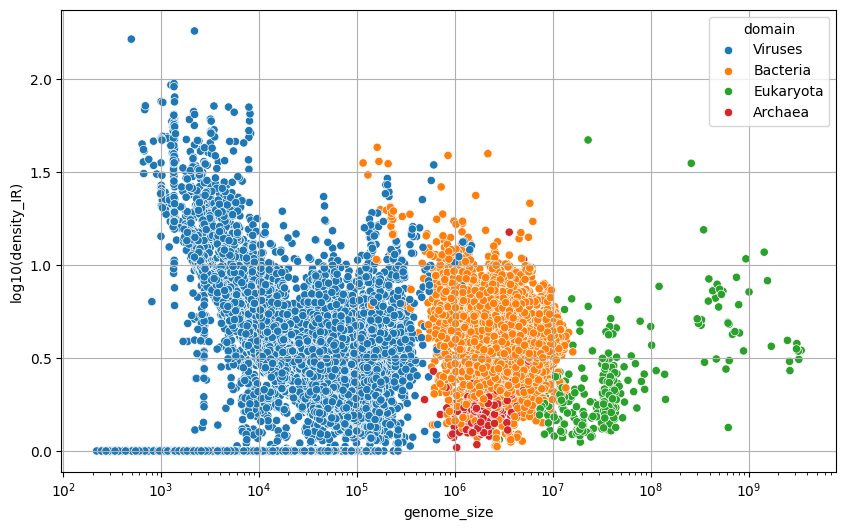

In [23]:
import seaborn as sns 
import matplotlib.pyplot as plt
if isinstance(df, pd.DataFrame):
    df = pl.from_pandas(df)
pdf = df.group_by("species_taxid").agg(
                                       pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                       pl.col("genome_size").mean().alias("genome_size"),
                                       pl.col("domain").first().alias("domain"),
                                       pl.col("gc_percent").mean().alias("gc_percent")
                                ).to_pandas().copy()
pdf.loc[:, f"log10(density_{pattern})"] = (pdf[f"density_{pattern}"]).apply(lambda x: math.log(x+1, 10))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
sns.scatterplot(data=pdf, x="genome_size", y=f"log10(density_{pattern})", hue="domain", ax=ax)
ax.grid()
# ax.set_yscale("log")
ax.set_xscale("log")

In [13]:
import numpy as np
from scipy.stats import spearmanr
from tqdm import tqdm 
pdf = df.group_by("species_taxid").agg(
                                       pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                       pl.col("genome_size").mean().alias("genome_size"),
                                       pl.col("domain").first().alias("domain"),
                                       pl.col("gc_percent").mean().alias("gc_percent")
                                ).to_pandas().copy()
domains = ["Eukaryota", "Archaea", "Viruses", "Bacteria"]
for domain in domains:
    sub_df = pdf[pdf["domain"] == domain]
    x = sub_df["genome_size"].to_numpy()
    y = sub_df[f"density_{pattern}"].to_numpy()
    n = len(sub_df)
    n_boot = 10000
    boot_rhos = np.empty(n_boot)

    for i in tqdm(range(n_boot)):
        idx = np.random.randint(0, n, n)  # bootstrap sample
        boot_rhos[i] = spearmanr(x[idx], y[idx]).correlation

    ci_lower, ci_upper = np.percentile(boot_rhos, [2.5, 97.5])
    rho_obs = spearmanr(x, y).correlation

    print("Observed Spearman ρ:", rho_obs)
    print("Bootstrap 95% CI:", (ci_lower, ci_upper))


100%|██████████| 10000/10000 [00:01<00:00, 7502.95it/s]


Observed Spearman ρ: 0.503296857394877
Bootstrap 95% CI: (np.float64(0.40203214886713573), np.float64(0.594562805855))


100%|██████████| 10000/10000 [00:01<00:00, 6385.25it/s]


Observed Spearman ρ: 0.5524792065703279
Bootstrap 95% CI: (np.float64(0.487589104610674), np.float64(0.6115352956602835))


100%|██████████| 10000/10000 [00:38<00:00, 260.66it/s]


Observed Spearman ρ: 0.25377544502309274
Bootstrap 95% CI: (np.float64(0.24148435815629576), np.float64(0.2658439138834832))


100%|██████████| 10000/10000 [00:15<00:00, 635.55it/s]

Observed Spearman ρ: 0.010897075540419483
Bootstrap 95% CI: (np.float64(-0.009293442822334127), np.float64(0.030884216901443984))


In [11]:
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options

options = Options()
options.add_argument("--headless")
service = Service("/Users/nikolchantzi/.local/share/mamba/envs/biolab/bin/geckodriver")
driver = webdriver.Firefox(service=service, options=options)

In [20]:
import pandas as pd 
import polars as pl 
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot, row
from bokeh.models import ColumnDataSource
from bokeh.io import export_png, export_svg
from bokeh.io import output_file
import numpy as np
import pandas as pd
import math
from scipy.stats import spearmanr
import os 
from bokeh.resources import INLINE
import os
# Set up notebook output

if isinstance(df, pd.DataFrame):
    df = pl.from_pandas(df)

pdf = df.group_by("species_taxid").agg(
                                       pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                       pl.col("genome_size").mean().alias("genome_size"),
                                       pl.col("domain").first().alias("domain"),
                                       pl.col("gc_percent").mean().alias("gc_percent")
                                ).to_pandas().copy()

domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
domain_colors = {
                'Viruses': '#229ad6',
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#0fbf2d'
}
plots = []
domains = pdf['domain'].unique()
pdf.loc[:, f"log10(density_{pattern})"] = (pdf[f"density_{pattern}"]).apply(lambda x: math.log(x+1, 10))
pdf.loc[:, "genome_size"] = pdf["genome_size"] / 1e6

annotation_positions = {
    'Archaea': {'x': 0.25, 'y': 0.80},
    'Bacteria': {'x': 0.2, 'y': 0.80},
    'Eukaryota': {'x': 0.3, 'y': 0.80},
    'Viruses': {'x': 0.1, 'y': 0.80}
}

for i, domain in enumerate(domains):
    sub = pdf[pdf['domain'] == domain]
    x = sub['genome_size'].tolist()
    y = sub[f'log10(density_{pattern})'].tolist()
    source  = ColumnDataSource(data=sub)
    p = figure(title=f"{domain}", 
               x_axis_label="Genome Size (Mb)", 
               y_axis_label=f"log₁₀({pattern} Density per kB+1)",
               width=1200, 
               height=700, 
               title_location="above", 
                output_backend="svg",
               toolbar_location=None)
    p.title.text_font_size = '34pt'
    p.title.align = 'center'
    p.xaxis.axis_label_text_font_style = "normal"
    p.yaxis.axis_label_text_font_style = "normal"
    p.xaxis.axis_label_text_font_size = "32pt"
    p.yaxis.axis_label_text_font_size = "32pt"
    p.xaxis.major_label_text_font_size = "30pt"
    p.yaxis.major_label_text_font_size = "30pt"
    p.scatter(x,
              y,
              size=10, 
              color=domain_colors.get(domain, "navy"), 
              alpha=0.7)
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        reg_x = np.linspace(min(x), max(x), 100)
        reg_y = coeffs[0] * reg_x + coeffs[1]
        p.line(list(reg_x), list(reg_y), color="black", line_width=3)
    if len(x) > 1:
        corr, pval = spearmanr(x, y)
        if pval < 0.0001:
            annotation = f"Spearman's r = {corr:.2f}\np-value < 0.0001"
        elif pval < 0.001:
            annotation = f"Spearman's r = {corr:.2f}\np-value < 0.001"
        elif pval < 0.01:
            annotation = f"Spearman's r = {corr:.2f}\np-value < 0.01"
        elif pval < 0.05:
            annotation = f"Spearman's r = {corr:.2f}\np-value < 0.05"
        else:
            annotation = f"Spearman's r = {corr:.2f}\np-value > 0.05"
            
        x_anno = min(x) + annotation_positions.get(domain, {'x':0.05})['x'] * (max(x) - min(x))
        y_anno = min(y) + annotation_positions.get(domain, {'y':0.95})['y'] * (max(y) - min(y))
        if domain == "Viruses":
            x_anno += 1.7
        elif domain == "Eukaryota":
            x_anno += 2000
        elif domain == "Bacteria":
            x_anno += 11
        else:
            x_anno += 5
        p.add_layout(bokeh.models.Label(x=x_anno, 
                                        y=y_anno + 0.07,
                                        x_units='data',
                                          y_units='data',
                                        x_offset=0, 
                                        y_offset=0,
                                        text=annotation,
                                        text_font_size="26pt",
                                        border_line_color="black",
                                        border_line_alpha=0.4,
                                        background_fill_color="white",
                                        background_fill_alpha=1.0,
                                        text_align="right"))

    p.border_fill_color = None
    plots.append(p)
    # p.y_range.start = 0
    # p.x_range.start = 0

from pathlib import Path
target = Path(f"{pattern}_figures/regression")
target.mkdir(exist_ok=True, parents=True)
for i, p in enumerate(plots):
    show(p)
    domain = p.title.text
    export_svg(p, filename=f"{target}/accessions_density_{pattern}_regplot_genome_size_domain_{domain}.svg", webdriver=driver)

In [21]:
import pandas as pd 
import polars as pl 
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot, row
from bokeh.models import ColumnDataSource
from bokeh.io import export_png, export_svgs
from bokeh.io import output_file
import numpy as np
import pandas as pd
import math
from scipy.stats import spearmanr
import os 

# Convert to pandas for easier manipulation
pdf = df.group_by("species_taxid").agg(
                                       pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                       pl.col("genome_size").mean().alias("genome_size"),
                                       pl.col("domain").first().alias("domain"),
                                       pl.col("phylum").first().alias("phylum"),
                                       pl.col("gc_percent").mean().alias("gc_percent")
                                ).to_pandas().copy()


THRESHOLD = 200
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
domain_colors = {
                'Viruses': '#229ad6',
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2'
}
domain_colors.update({"Bacteria": "#8eb812"})
plots = []
# pdf.loc[:, f"log10(density_{pattern})"] = (pdf[f"density_{pattern}"]).apply(lambda x: math.log(x+1, 10))

annotation_positions = {
    'Archaea': {'x': 0.95, 'y': 0.05},
    'Bacteria': {'x': 0.95, 'y': 0.05},
    'Eukaryota': {'x': 0.95, 'y': 0.05},
    'Viruses': {'x': 0.95, 'y': 0.05}
}
for i, domain in enumerate(domains):
    sub = pdf[pdf["domain"] == domain]
    x = sub['gc_percent']
    # y = sub[f'log10(density_{pattern})']
    # y = sub[f'density_{pattern}']
    y = sub[f'density_{pattern}']
    # source = ColumnDataSource(data=sub)
    p = figure(title=f"{domain}", 
               x_axis_label="GC Content", 
               # y_axis_label=f"log₁₀({pattern} Density per kB)",
               y_axis_label=f"{pattern} Density per kB",
               width=1200, 
               height=700, 
               title_location="above", 
                output_backend="svg",
               toolbar_location=None)
    p.title.text_font_size = '34pt'
    p.title.align = 'center'
    p.xaxis.axis_label_text_font_style = "normal"
    p.yaxis.axis_label_text_font_style = "normal"
    p.xaxis.axis_label_text_font_size = "32pt"
    p.yaxis.axis_label_text_font_size = "32pt"
    p.xaxis.major_label_text_font_size = "30pt"
    p.yaxis.major_label_text_font_size = "30pt"
    p.scatter(x.tolist(), 
              y.tolist(), size=10, color=domain_colors["Bacteria"], alpha=0.7)
    # Regression line
    if len(x) > 1:
        # coeffs = np.polyfit(x, y, 1)
        # reg_x = np.linspace(x.min(), x.max(), 100)
        # reg_y = coeffs[0] * reg_x + coeffs[1]
        coeffs = np.polyfit(x, y, 2)
        reg_x = np.linspace(x.min(), x.max(), 200)
        reg_y = coeffs[0] * reg_x**2 + coeffs[1] * reg_x + coeffs[2]
        y_pred = coeffs[0] * x**2 + coeffs[1] * x + coeffs[2]
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot
        p.line(list(reg_x), list(reg_y), color="black", line_width=3, line_dash='dashed')
    
    if len(x) > 1:
        corr, pval = spearmanr(x, y)
        print(domain, annotation)
        x_anno = x.min() + annotation_positions.get(domain, {'x':0.95})['x'] * (x.max() - x.min())
        y_anno = y.min() + annotation_positions.get(domain, {'y':0.05})['y'] * (y.max() - y.min())
        if domain == "Viruses":
            y_anno += 1.8
            x_anno -= 2.0
        elif domain == "Eukaryota":
            y_anno += 1.3
            x_anno -= 5
        elif domain == "Bacteria":
            y_anno += 3.3
            x_anno -= 10
        else:
            y_anno += 0.9
            x_anno -= 10
        y_anno += 30
        annotation = f"R² = {r2:.2f}\nSpearman r = {corr:.2f}\np = {pval:.3f}"
        p.add_layout(bokeh.models.Label(
            x=x_anno,
            y=y_anno,
            x_units='data',
            y_units='data',
            x_offset=0,
            y_offset=0,
            text=annotation,
            text_font_size="20pt",
            border_line_color="black",
            border_line_alpha=0.4,
            background_fill_color="white",
            background_fill_alpha=1.0,
            text_align="right"
        ))
    p.border_fill_color = None
    plots.append(p)

target = Path(f"{pattern}_figures/regression")
for i, p in enumerate(plots):
    # show(p, notebook_handle=True)
    domain = p.title.text
    export_svg(p, filename=f"{target}/accessions_density_{pattern}_regplot_gc_percent_{domain}.svg")
    show(p)

Archaea R² = 0.00
Spearman r = 0.00
p = 0.566
Eukaryota R² = 0.26
Spearman r = 0.40
p = 0.000
Bacteria R² = 0.33
Spearman r = -0.47
p = 0.000
Viruses R² = 0.26
Spearman r = -0.13
p = 0.000


In [16]:
from scipy import stats
import numpy as np
from seaborn.algorithms import bootstrap
from seaborn.utils import ci
# Calculate average and std STR density per superkingdom

def ci95(series):
    n = len(series)
    if isinstance(series, pl.Series):
        series = series.to_pandas()
    mean = series.mean()
    std = series.std(ddof=1)
    t = stats.t.ppf(0.975, n - 1)
    return t * (std / np.sqrt(n))

def seaborn_ci(series):
    boot_means = bootstrap(series, 
                           func=np.mean, 
                           n_boot=1000, 
                           seed=42)
    ci_bounds = ci(boot_means, 95)
    lower_ci, upper_ci = ci_bounds
    print(lower_ci, upper_ci)
    return pd.Series({"lower_ci": lower_ci, "upper_ci": upper_ci})

def calculate_average_density(df, on, value):
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
    # df[value] = df[value] * 1e3 
    grouped = df.groupby(on)[value]
    mean = grouped.mean().reset_index(name='mean')
    ci_intervals = grouped.apply(seaborn_ci).reset_index()

    avg_value = pd.merge(mean, 
                     ci_intervals.query("level_1=='upper_ci'"), 
                     on=on, 
                     how='left')\
                    .merge(ci_intervals.query("level_1=='lower_ci'"), 
                           on=on,
                           how='left')\
                    .rename(columns={
                                     f'{value}_x': 'upper_ci', 
                                     f'{value}_y': 'lower_ci'
                                     })\
                    .drop(columns=["level_1_x", "level_1_y"])\
                    .sort_values('mean', ascending=False)
    return avg_value
# agg.loc[:, "lower_ci"] = agg['mean'] - agg['ci']
# agg.loc[:, "upper_ci"] = agg['mean'] + agg['ci']

df_avged = df.group_by("species_taxid").agg(
                                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                        pl.col("domain").first().alias("domain"),
                                        pl.col("genome_size").mean().alias("genome_size"),
                                        pl.col("gc_percent").mean().alias("gc_percent"),
                                        pl.col("organism_name").first().alias("organism_name"),
                                        pl.col("kingdom").first().alias("kingdom"),
                                        pl.col("phylum").first().alias("phylum"),
)
avg_value = calculate_average_density(df_avged, on="domain", value=f"density_{pattern}")
avg_value

1.140896430334186 1.3370880484994014
3.1093459534589325 3.177903849672692
1.537070765519229 2.3693436517565076
1.8796412869936 1.985193297620097


,domain,mean,upper_ci,lower_ci
1,Bacteria,3.142678,3.177904,3.109346
3,Viruses,1.932170,1.985193,1.879641
2,Eukaryota,1.912058,2.369344,1.537071
0,Archaea,1.230677,1.337088,1.140896


In [17]:
df_avged.group_by("domain").agg(pl.col(f"density_{pattern}").mean()).sort(f"density_{pattern}", descending=True)

domain,density_IR
str,f64
"""Bacteria""",3.142678
"""Viruses""",1.93217
"""Eukaryota""",1.912058
"""Archaea""",1.230677


In [18]:
df["density_ungapped_IR"].min()

0.0

In [19]:
df.group_by("species_taxid").agg(pl.col("density_ungapped_IR").mean())["density_ungapped_IR"].median()

1.306

In [21]:
from bokeh.plotting import figure, show
from pathlib import Path
from bokeh.models import ColumnDataSource, Whisker
from scipy import stats
import numpy as np
from seaborn.algorithms import bootstrap
from seaborn.utils import ci
# Calculate average and std STR density per superkingdom

domain_colors = {
                'Viruses': '#229ad6',
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#0fbf2d'
}
# domain_colors.update({"Bacteria": "#8eb812"})

domains_sorted = avg_value["domain"].tolist()
avg_value['color'] = avg_value['domain'].map(domain_colors)

source = ColumnDataSource(avg_value)

bar_fig = figure(x_range=domains_sorted, 
                 height=700, 
                 width=900, 
                 border_fill_color=None,
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")
bar_fig.vbar(x='domain', 
             top='mean', 
             width=0.7, 
             line_color='black',
             line_width=1.5,
             color='color', 
             source=source)

# Add error bars (std)
error = Whisker(source=source, 
                           base='domain', 
                           upper='upper_ci', 
                           lower='lower_ci', 
                           level='overlay')
error.upper_head.size = 20
error.lower_head.size = 20

bar_fig.add_layout(error)
bar_fig.xgrid.grid_line_color = None
bar_fig.y_range.start = 0
bar_fig.y_range.end = avg_value['upper_ci'].max() * 1.1
bar_fig.xaxis.axis_label = ""
bar_fig.yaxis.axis_label = f"{pattern} Density per kB"
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "30pt"
bar_fig.yaxis.axis_label_text_font_size = "30pt"
bar_fig.xaxis.major_label_text_font_size = "32pt"
bar_fig.yaxis.major_label_text_font_size = "30pt"
bar_fig.title.text_font_size = '22pt'
bar_fig.title.align = 'center'

target = Path(f"{pattern}_figures/regression")
export_svgs(bar_fig, filename=f"{target}/domain_{pattern}_densities.svg", webdriver=driver)
show(bar_fig)

In [22]:
from bokeh.models import ColumnDataSource, Whisker
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap, jitter

domains = ["Bacteria", "Eukaryota", "Viruses", "Archaea"]
p = figure(height=500,
           width=800, 
           x_range=domains,
           toolbar_location=None,
           output_backend="svg",
           title="" 
)
p.y_range.end = 55
p.xgrid.grid_line_color = None
g = ( 
    df_avged.group_by("domain")
    .agg(pl.col(f"density_{pattern}").quantile(0.975).alias(f"upper_density_{pattern}"),
         pl.col(f"density_{pattern}").quantile(0.025).alias(f"lower_density_{pattern}"),
         color=pl.col("domain").first().alias("color")
    )
)
upper = g[f"upper_density_{pattern}"].to_pandas()
lower = g[f"lower_density_{pattern}"].to_pandas()
color = g["domain"].replace_strict(domain_colors).to_pandas()
source = ColumnDataSource(data=dict(base=domains, upper=upper, lower=lower, color=color))
source = ColumnDataSource(data=g.to_pandas())

error = Whisker(base="domain", 
                upper=f"upper_density_{pattern}", 
                lower=f"lower_density_{pattern}", 
                source=source,
                level="annotation", 
                line_width=4)
error.upper_head.size=35
error.lower_head.size=35
p.add_layout(error)

df_avged_samples = []
df_avged = df_avged.with_columns(color=pl.col("domain").replace_strict(domain_colors))
proportions = {"Eukaryota": 1.0,
               "Archaea": 1.0,
               "Bacteria": 1.0,
               "Viruses": 1.0}
for domain in domains:
    df_avged_sample = df_avged.filter(pl.col("domain") == domain)
    df_avged_sample = df_avged_sample.sample(n=int(df_avged_sample.shape[0] * proportions[domain]), with_replacement=False, seed=42)
    df_avged_samples.append(df_avged_sample.select(["domain", f"density_{pattern}", "color"]))
df_avged_samples = pl.concat(df_avged_samples)

p.scatter(jitter("domain", 0.2, range=p.x_range), 
          f"density_{pattern}", 
          source=df_avged_samples,
          alpha=0.2, size=13, line_color="white",
          color="color",
          # color=factor_cmap("domain", "Light7", domains)
          )

p.xaxis.axis_label = ""
p.yaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"
p.xaxis.axis_label_text_font_size = "30pt"
p.yaxis.axis_label_text_font_size = "30pt"
p.xaxis.major_label_text_font_size = "28pt"
p.yaxis.major_label_text_font_size = "30pt"
p.title.text_font_size = '22pt'
p.title.align = 'center'

target = Path(f"{pattern}_figures/regression")
export_svg(p, filename=f"{target}/domain_{pattern}_densities_jitter.svg", webdriver=driver)
show(p)

In [23]:
df.filter(pl.col("partition") == ".").unique(["species_taxid"])["domain"].value_counts()

domain,count
str,u32
"""Archaea""",528
"""Eukaryota""",290
"""Bacteria""",11118
"""Viruses""",32106


In [24]:
df.filter(pl.col("partition") == ".", pl.col(f"density_{pattern}") <=0 ).unique(["species_taxid"])["domain"].value_counts()

domain,count
str,u32
"""Viruses""",14727
"""Bacteria""",1


In [25]:
df.filter(pl.col("partition") == ".")["domain"].value_counts()

domain,count
str,u32
"""Viruses""",67654
"""Bacteria""",49191
"""Archaea""",687
"""Eukaryota""",487


In [26]:
df.filter(pl.col("partition") == ".", pl.col(f"density_{pattern}") <=0 )["domain"].value_counts()

domain,count
str,u32
"""Bacteria""",1
"""Viruses""",32860


## Kingdom Density

In [27]:
mean_density_kingdom = df.filter(~pl.col("kingdom").is_null())\
                        .group_by("kingdom").agg(pl.col(f"density_{pattern}").mean().alias("mean_density"))\
                        .sort("mean_density", descending=True)
mean_density_kingdom.to_pandas()

,kingdom,mean_density
0,Protista,4.796781
1,Metazoa,4.548360
2,Plantae,4.224327
3,Bacillati,3.667323
4,Fusobacteriati,3.283960
5,Pseudomonadati,3.092954
6,Shotokuvirae,3.027425
7,Sangervirae,2.992636
8,Thermotogati,2.873596
9,Loebvirae,2.624669


In [46]:
domain_colors

{'Viruses': '#229ad6',
 'Eukaryota': '#edc41f',
 'Bacteria': '#0fbf2d',
 'Archaea': '#b2b2ff'}

In [47]:
df = df.with_columns(
    kingdom_n=pl.struct(["kingdom", "domain"]).map_elements(lambda x: x["kingdom"] if x["domain"] != "Viruses" else "Viruses", return_dtype=pl.Utf8)
)

kingdom_color_palette = {'Viruses':'#229ad6',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                        'Thermoproteati': '#380e8c',
                         'Promethearchaeati': '#672fd6',
                         'Nanobdellati': '#8154eb',
                         'Methanobacteriati': '#1fc46a',
                         'Fusobacteriati': '#0fbf2d',
                         'Pseudomonadati': '#0fbf2d',
                         'Bacillati': '#0fbf2d',
                     'Thermotogati': '#0fbf2d'
                     }

df_temp = df.filter(~pl.col("kingdom").is_null())
kingdom_to_colors = dict(zip(df_temp["kingdom"], df_temp["kingdom_n"]))
kingdom_to_colors = {k: kingdom_color_palette[v] for k, v in kingdom_to_colors.items()}
kingdom_to_colors

{'Pseudomonadati': '#0fbf2d',
 'Bacillati': '#0fbf2d',
 'Orthornavirae': '#229ad6',
 'Shotokuvirae': '#229ad6',
 'Heunggongvirae': '#229ad6',
 'Zilligvirae': '#229ad6',
 'Pararnavirae': '#229ad6',
 'Bamfordvirae': '#229ad6',
 'Sangervirae': '#229ad6',
 'Loebvirae': '#229ad6',
 'Fungi': '#4d325e',
 'Methanobacteriati': '#1fc46a',
 'Metazoa': '#9bba2d',
 'Thermotogati': '#0fbf2d',
 'Thermoproteati': '#380e8c',
 'Fusobacteriati': '#0fbf2d',
 'Protista': '#c78f5b',
 'Trapavirae': '#229ad6',
 'Abadenavirae': '#229ad6',
 'Plantae': '#b50996',
 'Helvetiavirae': '#229ad6',
 'Promethearchaeati': '#672fd6',
 'Nanobdellati': '#8154eb'}

In [29]:
def ci95(series):
    n = len(series)
    if isinstance(series, pl.Series):
        series = series.to_pandas()
    mean = series.mean()
    std = series.std(ddof=1)
    t = stats.t.ppf(0.975, n - 1)
    return t * (std / np.sqrt(n))

In [30]:

mean_density_kingdom = df.filter(~pl.col("kingdom").is_null())\
                        .group_by("species_taxid")\
                        .agg(
                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                pl.col("genome_size").mean().alias("genome_size"),
                                pl.col("domain").first().alias("domain"),
                                pl.col("kingdom").first().alias("kingdom"),
                                pl.col("phylum").first().alias("phylum"),
                        ).to_pandas()\
                        .groupby("kingdom")[f"density_{pattern}"].apply(ci95)
mean_density_kingdom

kingdom
Abadenavirae         0.925399
Bacillati            0.058915
Bamfordvirae         0.487144
Fungi                0.120041
Fusobacteriati       0.470486
Helvetiavirae        1.133873
Heunggongvirae       0.023720
Loebvirae            0.372776
Metazoa              3.092205
Methanobacteriati    0.120476
Nanobdellati         0.747640
Orthornavirae        0.116010
Pararnavirae         0.202872
Plantae              0.972645
Promethearchaeati    0.091742
Protista             4.427058
Pseudomonadati       0.043790
Sangervirae          0.276964
Shotokuvirae         0.243721
Thermoproteati       0.079546
Thermotogati         0.339089
Trapavirae           0.953292
Zilligvirae          0.485284
Name: density_IR, dtype: float64

In [31]:
from pathlib import Path 

target = Path(f"{pattern}_figures/regression")
mean_density_kingdom = df.filter(~pl.col("kingdom").is_null())\
                        .group_by("species_taxid")\
                        .agg(
                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                pl.col("genome_size").mean().alias("genome_size"),
                                pl.col("domain").first().alias("domain"),
                                pl.col("kingdom").first().alias("kingdom"),
                                pl.col("phylum").first().alias("phylum"),
                        )\
                        .to_pandas()\
                        .groupby("kingdom", as_index=False).agg(
                                                                      mean_density=(f"density_{pattern}", "mean"),
                                                                      domain=("domain", "first"),
                                                                      confidence=(f"density_{pattern}", ci95)
                                                        )
mean_density_kingdom = pl.from_pandas(mean_density_kingdom)\
                        .sort("mean_density", descending=False)\
                        .with_columns(
                                kingdom_color=pl.struct(["domain", "kingdom"]).map_elements(lambda y: kingdom_color_palette[y['domain']] if y['domain'] in {"Viruses", "Archaea", "Bacteria"} \
                                                                                                                   else kingdom_color_palette[y['kingdom']],
                                                                                                                   return_dtype=pl.Utf8),
                                lower_ci=pl.col("mean_density") - pl.col("confidence"),
                                upper_ci=pl.col("mean_density") + pl.col("confidence"),
                        )
mean_density_kingdom.write_csv(f"{target}/mean_coverage_{pattern}_kingdom_level.csv")
mean_density_kingdom

kingdom,mean_density,domain,confidence,kingdom_color,lower_ci,upper_ci
str,f64,str,f64,str,f64,f64
"""Thermoproteati""",0.666222,"""Archaea""",0.079546,"""#b2b2ff""",0.586676,0.745768
"""Promethearchaeati""",0.7078,"""Archaea""",0.091742,"""#b2b2ff""",0.616058,0.799542
"""Pararnavirae""",0.784247,"""Viruses""",0.202872,"""#229ad6""",0.581375,0.98712
"""Fungi""",1.004787,"""Eukaryota""",0.120041,"""#4d325e""",0.884746,1.124827
"""Nanobdellati""",1.146643,"""Archaea""",0.74764,"""#b2b2ff""",0.399003,1.894283
…,…,…,…,…,…,…
"""Sangervirae""",3.477884,"""Viruses""",0.276964,"""#229ad6""",3.200919,3.754848
"""Bacillati""",3.575349,"""Bacteria""",0.058915,"""#0fbf2d""",3.516434,3.634263
"""Protista""",3.94446,"""Eukaryota""",4.427058,"""#c78f5b""",-0.482597,8.371518


In [53]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Whisker
from scipy import stats
from pathlib import Path
import numpy as np

avg_kingdom_density = calculate_average_density(df.group_by("species_taxid")\
                                                .agg(
                                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                                    pl.col("genome_size").mean().alias("genome_size"),
                                                    pl.col("domain").first().alias("domain"),
                                                    pl.col("kingdom").first().alias("kingdom"),
                                                    pl.col("phylum").first().alias("phylum"),
                                                ).filter(~pl.col("kingdom").is_null()), 
                                                on="kingdom", 
                                                value=f"density_{pattern}")

# avg_kingdom_density = apply_iterative_averaging(df.filter(~pl.col("kingdom").is_null()), up_to="order", stop_at="order")\
#                                          .sort(f"density_{pattern}", descending=True)
# avg_kingdom_density = calculate_average_density(avg_kingdom_density, on="kingdom", value=f"density_{pattern}")
print(avg_kingdom_density)
avg_kingdom_density.loc[:, "kingdom_color"] = avg_kingdom_density["kingdom"].map(kingdom_to_colors)
avg_kingdom_density = avg_kingdom_density.sort_values("mean", ascending=True)

source = ColumnDataSource(avg_kingdom_density)
domains_sorted = list(avg_kingdom_density['kingdom'])

bar_fig = figure(y_range=domains_sorted, 
                 height=1600, 
                 width=700, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")

bar_fig.hbar(y='kingdom', 
             right='mean', 
             height=0.7, 
             line_color='black',
             line_width=1.5,
             color='kingdom_color', 
             source=source)

# Add horizontal error bars
error = Whisker(source=source, 
                base='kingdom', 
                upper='upper_ci', 
                lower='lower_ci',
                dimension='width', 
                level='overlay')

error.line_width = 2
error.upper_head.size = 20
error.lower_head.size = 20
bar_fig.add_layout(error)

bar_fig.ygrid.grid_line_color = None
# bar_fig.x_range.start = avg_kingdom_density['lower_ci'].min() * 0.9
bar_fig.x_range.end = avg_kingdom_density['upper_ci'].max() * 1.1
bar_fig.xaxis.axis_label = f"{pattern} Density per kB"
bar_fig.yaxis.axis_label = ""
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "26pt"
bar_fig.yaxis.axis_label_text_font_size = "24pt"
bar_fig.xaxis.major_label_text_font_size = "24pt"
bar_fig.yaxis.major_label_text_font_size = "30pt"
bar_fig.title.text_font_size = '24pt'
bar_fig.title.align = 'center'

target = Path(f"{pattern}_figures/regression")
export_svgs(bar_fig, filename=f"{target}/kingdom_{pattern}_densities_horizontal.svg", webdriver=driver)
show(bar_fig)


              kingdom      mean  upper_ci  lower_ci
8             Metazoa  4.611705  7.750736  2.560969
13            Plantae  4.491167  5.377757  3.674836
15           Protista  3.944460  8.487092  1.425356
1           Bacillati  3.575349  3.633176  3.517927
17        Sangervirae  3.477884  3.766231  3.222291
2        Bamfordvirae  3.416734  3.941348  2.947373
4      Fusobacteriati  3.131650  3.581753  2.673247
20       Thermotogati  3.035025  3.365604  2.704956
18       Shotokuvirae  2.984780  3.223220  2.745172
16     Pseudomonadati  2.861291  2.900033  2.814835
0        Abadenavirae  2.359833  3.244280  1.577990
7           Loebvirae  1.853448  2.242957  1.457911
11      Orthornavirae  1.631520  1.754957  1.518626
21         Trapavirae  1.494143  2.395044  0.762237
9   Methanobacteriati  1.394561  1.536187  1.281656
6      Heunggongvirae  1.348180  1.373201  1.324376
22        Zilligvirae  1.290022  1.770654  0.860739
5       Helvetiavirae  1.205222  2.203667  0.329556
10       Nan

In [33]:
from bokeh.models import ColumnDataSource, Whisker
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap, jitter

domains = ["Bacteria", "Eukaryota", "Viruses", "Archaea"]
reduced_df = (
    df.group_by("species_taxid")\
                .agg(
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                        pl.col("domain").first().alias("domain"),
                        pl.col("kingdom").first().alias("kingdom"),
                        pl.col("genus").first().alias("genus"),
                        pl.col("family").first().alias("family"),
                    )
                .filter(~pl.col("kingdom").is_null())
)
avg_kingdom_density = ( 
                                        reduced_df.group_by("kingdom")
                                        .agg(
                                            pl.col(f"density_{pattern}").mean().alias("mean_density"),
                                            pl.col("domain").first().alias("domain"),
                                            pl.col(f"density_{pattern}").quantile(0.8).alias(f"upper_density_{pattern}"),
                                            pl.col(f"density_{pattern}").quantile(0.2).alias(f"lower_density_{pattern}"),
                                        )
)
upper = avg_kingdom_density[f"upper_density_{pattern}"].to_pandas()
lower = avg_kingdom_density[f"lower_density_{pattern}"].to_pandas()
reduced_df = reduced_df.with_columns(color=pl.col("kingdom").replace_strict(kingdom_color_palette, default=domain_colors["Viruses"]))
# color = avg_kingdom_density["kingdom"].replace_strict(kingdom_color_palette).to_pandas()

domains_sorted = list(avg_kingdom_density.sort("mean_density")['kingdom'])
p = figure(y_range=domains_sorted, 
                 height=1600, 
                 width=900, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")

# # # # #
source = ColumnDataSource(avg_kingdom_density.to_pandas())
error = Whisker(base="kingdom", 
                upper=f"upper_density_{pattern}", 
                lower=f"lower_density_{pattern}", 
                source=source,
                dimension='width',
                level="annotation", 
                line_width=4)

error.upper_head.size=35
error.lower_head.size=35
p.add_layout(error)

taxonomic_rank = "genus"
data = reduced_df.group_by(taxonomic_rank)\
                                    .agg(
                                        pl.col("color").first().alias("color"),
                                        pl.col("kingdom").first().alias("kingdom"),
                                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    ).to_pandas()
source = ColumnDataSource(data)                            
p.scatter(
          f"density_{pattern}",
          jitter("kingdom", 0.2, range=p.y_range), 
          source=source,
          alpha=0.4, 
          size=20, 
          line_color="white",
          color="color",
          # color=factor_cmap("domain", "Light7", domains)
          )
# p.xgrid.grid_line_color = None
p.x_range.start = 0
p.x_range.end = 2.5 * avg_kingdom_density[f"upper_density_{pattern}"].max()
p.yaxis.axis_label = ""
p.xaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"
p.xaxis.axis_label_text_font_size = "36pt"
p.yaxis.axis_label_text_font_size = "30pt"
p.xaxis.major_label_text_font_size = "32pt"
p.yaxis.major_label_text_font_size = "32pt"
p.title.text_font_size = '22pt'
p.title.align = 'center'

target = Path(f"{pattern}_figures/regression")
export_svgs(p, filename=f"{target}/kingdom_{pattern}_densities_{taxonomic_rank}_jitter.svg", webdriver=driver)
show(p)

## Phylum Level STR density

In [34]:
mean_density_phyla = (
                    df.group_by("species_taxid")\
                        .agg(
                            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                            pl.col("genome_size").mean().alias("genome_size"),
                            pl.col("domain").first().alias("domain"),
                            pl.col("kingdom").first().alias("kingdom"),
                            pl.col("phylum").first().alias("phylum"),
                        ).filter(~pl.col("phylum").is_null())
                        .group_by("phylum", maintain_order=False)
                        .agg(
                            mean_coverage=pl.col(f"density_{pattern}").mean(),
                            domain=pl.col("domain").first(),
                            total_species=pl.col("domain").count(),
                            kingdom=pl.col("kingdom").first(),
                        )
                    .sort(by=["mean_coverage"], descending=True)
)
mean_density_phyla = mean_density_phyla.to_pandas()
target = Path(f"{pattern}_figures/regression")
mean_density_phyla.to_csv(f"{target}/mean_coverage_{pattern}_phylum_level.csv")
mean_density_phyla.head(40)


,phylum,mean_coverage,domain,total_species,kingdom
0,Candidatus Campbelliibacteriota,11.991000,Bacteria,2,None
1,Candidatus Kaiseribacteriota,9.752500,Bacteria,1,None
2,Candidatus Wolfeibacteriota,8.673000,Bacteria,1,None
3,Candidatus Altimarinota,7.548083,Bacteria,3,None
4,Arthropoda,7.327143,Eukaryota,7,Metazoa
5,Apicomplexa,6.690267,Eukaryota,10,Protista
6,Mycoplasmatota,6.614467,Bacteria,198,Bacillati
7,Candidatus Uhriibacteriota,5.783000,Bacteria,1,None
8,Nucleocytoviricota,5.738702,Viruses,193,Bamfordvirae
9,Streptophyta,5.267224,Eukaryota,26,Plantae


In [35]:
top_phyla = set(mean_density_phyla.iloc[:mean_density_phyla.shape[0]//2]['phylum'])
bottom_phyla = set(mean_density_phyla.iloc[mean_density_phyla.shape[0]//2:]['phylum'])
len(top_phyla), len(bottom_phyla), mean_density_phyla.shape[0]

(64, 64, 128)

In [36]:
df = df.with_columns(
    kingdom_n=pl.struct(["kingdom", "domain"]).map_elements(lambda x: "Bacteria" if x["domain"] == "Bacteria" else ("Archaea" if x["domain"] == "Archaea" else ("Viruses" if x["domain"] == "Viruses" else x["kingdom"])), return_dtype=pl.Utf8)
)

In [37]:
phyla_all = (
                df.filter(~pl.col("phylum").is_null())
                    .group_by("species_taxid")
                    .agg(
                        pl.col("domain").first(),
                        pl.col("kingdom").first(),
                        pl.col("kingdom_n").first(),
                        pl.col("phylum").first(),
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}")
                    )
            )
            
top_phyla_df = phyla_all.filter(pl.col("phylum").is_in(top_phyla)) 
bottom_phyla_df = phyla_all.filter(pl.col("phylum").is_in(bottom_phyla)) 
len(top_phyla_df), len(bottom_phyla_df)

(15287, 24668)

In [38]:
list(df["kingdom_n"].unique())

['Bacteria', 'Metazoa', 'Plantae', 'Fungi', 'Protista', 'Viruses', 'Archaea']

In [39]:
top_phyla_df = top_phyla_df.with_columns(
                                kingdom_color=pl.col("kingdom_n").replace_strict(kingdom_color_palette)
)
bottom_phyla_df = bottom_phyla_df.with_columns(
                                kingdom_color=pl.col("kingdom_n").replace_strict(kingdom_color_palette)
)
top_phyla_df

species_taxid,domain,kingdom,kingdom_n,phylum,density_IR,kingdom_color
i64,str,str,str,str,f64,str
887827,"""Viruses""","""Shotokuvirae""","""Viruses""","""Cressdnaviricota""",11.516,"""#229ad6"""
2585443,"""Viruses""","""Sangervirae""","""Viruses""","""Phixviricota""",4.16,"""#229ad6"""
3052091,"""Bacteria""","""Bacillati""","""Bacteria""","""Bacillota""",7.855,"""#0fbf2d"""
38303,"""Bacteria""","""Bacillati""","""Bacteria""","""Actinomycetota""",1.267,"""#0fbf2d"""
2846030,"""Viruses""","""Orthornavirae""","""Viruses""","""Lenarviricota""",0.0,"""#229ad6"""
…,…,…,…,…,…,…
33932,"""Bacteria""","""Bacillati""","""Bacteria""","""Bacillota""",3.831,"""#0fbf2d"""
2929367,"""Viruses""","""Sangervirae""","""Viruses""","""Phixviricota""",0.0,"""#229ad6"""
2976822,"""Bacteria""","""Pseudomonadati""","""Bacteria""","""Pseudomonadota""",2.535,"""#0fbf2d"""


In [40]:
top_phyla_df["domain"].value_counts()

domain,count
str,u32
"""Eukaryota""",67
"""Viruses""",4740
"""Bacteria""",10478
"""Archaea""",2


In [41]:
def seaborn_ci(series):
    if isinstance(series, pl.Series):
        series = series.to_pandas()
    n = len(series)
    mean = series.mean() if n > 0 else np.nan
    if n < 2:
        return pd.Series({"lower_ci": mean, "upper_ci": mean})
    try:
        boot_means = bootstrap(series, func=np.mean, n_boot=1000, seed=42)
        ci_bounds = ci(boot_means, 95)
        lower_ci, upper_ci = ci_bounds
        # sanity: if CI contains nan or degenerate, fallback to mean
        if np.isnan(lower_ci) or np.isnan(upper_ci):
            return pd.Series({"lower_ci": mean, "upper_ci": mean})
        return pd.Series({"lower_ci": lower_ci, "upper_ci": upper_ci})
    except Exception:
        return pd.Series({"lower_ci": mean, "upper_ci": mean})

def calculate_average_density(df, on, value):
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
    grouped = df.groupby(on)[value]
    mean = grouped.mean().reset_index(name='mean')
    ci_intervals = grouped.apply(seaborn_ci).reset_index()

    avg_value = pd.merge(mean,
                         ci_intervals.query("level_1=='upper_ci'"),
                         on=on,
                         how='left') \
                  .merge(ci_intervals.query("level_1=='lower_ci'"),
                         on=on,
                         how='left') \
                  .rename(columns={
                      f'{value}_x': 'upper_ci',
                      f'{value}_y': 'lower_ci'
                  }) \
                  .drop(columns=["level_1_x", "level_1_y"], errors='ignore') \
                  .sort_values('mean', ascending=False)

    # fill missing CI with the group's mean so rows with single species are kept
    avg_value['upper_ci'] = avg_value['upper_ci'].fillna(avg_value['mean'])
    avg_value['lower_ci'] = avg_value['lower_ci'].fillna(avg_value['mean'])

    return avg_value

# agg.loc[:, "lower_ci"] = agg['mean'] - agg['ci']
# agg.loc[:, "upper_ci"] = agg['mean'] + agg['ci']
df_avged = df.group_by("species_taxid").agg(
                                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                        pl.col("domain").first().alias("domain"),
                                        pl.col("genome_size").mean().alias("genome_size"),
                                        pl.col("gc_percent").mean().alias("gc_percent"),
                                        pl.col("organism_name").first().alias("organism_name"),
                                        pl.col("kingdom").first().alias("kingdom"),
                                        pl.col("phylum").first().alias("phylum"),
)
avg_value = calculate_average_density(df_avged, on="domain", value=f"density_{pattern}")
avg_value

,domain,mean,upper_ci,lower_ci
1,Bacteria,3.142678,3.179892,3.108379
3,Viruses,1.932170,1.984091,1.883670
2,Eukaryota,1.912058,2.378978,1.524702
0,Archaea,1.230677,1.330308,1.136785


In [42]:

top_phyla_df_avg = calculate_average_density(top_phyla_df, on="phylum", value=f"density_{pattern}")
top_phyla_df = top_phyla_df.with_columns(kingdom_nn=pl.struct(["kingdom_n", "domain"])
                                         .map_elements(lambda x: x["kingdom_n"] if x["domain"] == "Eukaryota" else x["domain"],
                                                                                                            return_dtype=str))
phylum_to_kingdom_color = dict(zip(top_phyla_df["phylum"], top_phyla_df["kingdom_nn"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
top_phyla_df_avg.loc[:, "kingdom_color"] = top_phyla_df_avg["phylum"].map(phylum_to_kingdom_color)
top_phyla_df_avg = top_phyla_df_avg.sort_values(by=["mean"], ascending=True).reset_index(drop=True)
top_phyla_df_avg.head(10)

,phylum,mean,upper_ci,lower_ci,kingdom_color
0,Chlorobiota,1.893176,2.060184,1.733103,#0fbf2d
1,Candidatus Absconditibacteriota,1.931000,2.313000,1.499000,#0fbf2d
2,Candidatus Hydrogenedentota,1.962000,1.962000,1.962000,#0fbf2d
3,Ignavibacteriota,1.970485,2.243014,1.680763,#0fbf2d
4,Candidatus Zixiibacteriota,1.972500,1.972500,1.972500,#0fbf2d
5,Chlamydiota,1.985666,2.164223,1.804900,#0fbf2d
6,Candidatus Peregrinibacteriota,2.005711,2.871000,1.424333,#0fbf2d
7,Candidatus Kapaibacteriota,2.007000,2.007000,2.007000,#0fbf2d
8,Armatimonadota,2.014036,3.120000,1.005357,#0fbf2d
9,Calditrichota,2.049000,2.049000,2.049000,#0fbf2d


In [43]:
source = ColumnDataSource(top_phyla_df_avg)
domains_sorted = list(top_phyla_df_avg['phylum'])
bar_fig = figure(y_range=domains_sorted, 
                 height=2000, 
                 width=800, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")
bar_fig.border_fill_color = None
bar_fig.hbar(
             y='phylum', 
             right='mean', 
             height=0.8, 
             line_color='black',
             line_width=2.5,
             color='kingdom_color', 
             source=source
             )

# Add horizontal error bars
error = Whisker(source=source, 
                           base='phylum', 
                           upper='upper_ci', 
                           lower='lower_ci',
                           dimension='width', 
                           level='overlay')

error.line_width = 1.0
error.upper_head.size = 10
error.lower_head.size = 10
bar_fig.add_layout(error)

bar_fig.ygrid.grid_line_color = None
bar_fig.x_range.start = 0
bar_fig.x_range.end = top_phyla_df_avg['upper_ci'].max() * 1.1
bar_fig.xaxis.axis_label = f"{pattern} Density per kB"
bar_fig.yaxis.axis_label = ""
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "26pt"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.major_label_text_font_size = "26pt"
bar_fig.yaxis.major_label_text_font_size = "22pt"
bar_fig.title.text_font_size = '16pt'
bar_fig.title.align = 'center'
export_svgs(bar_fig, filename=f"{target}/phylum_{pattern}_densities_top_phyla.svg", webdriver=driver)
show(bar_fig)


In [52]:
from bokeh.models import ColumnDataSource, Whisker
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap, jitter

# # # # # # # # 
domains = ["Bacteria", "Eukaryota", "Viruses", "Archaea"]

domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                 'Bacteria': '#0fbf2d',
                 'Archaea': '#b2b2ff',                
            }


reduced_df = (
    df.group_by("species_taxid")\
                .agg(
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                        pl.col("domain").first().alias("domain"),
                        pl.col("kingdom").first().alias("kingdom"),
                        pl.col("phylum").first().alias("phylum"),
                        pl.col("genus").first().alias("genus"),
                        pl.col("family").first().alias("family"),
                    )
                .filter(~pl.col("phylum").is_null())
)

# # # # # # # # # # # #
avg_kingdom_density = ( 
                                        reduced_df.group_by("phylum")
                                        .agg(
                                            pl.col(f"density_{pattern}").mean().alias("mean_density"),
                                            pl.col("domain").first().alias("domain"),
                                            pl.col(f"density_{pattern}").quantile(0.2).alias(f"lower_density_{pattern}"),
                                            pl.col(f"density_{pattern}").quantile(0.8).alias(f"upper_density_{pattern}"),
                                        )
                                        .sort("mean_density", descending=True)
)

avg_kingdom_density = avg_kingdom_density.head(avg_kingdom_density.shape[0]//2)
phylums_sorted = list(avg_kingdom_density.sort("mean_density", descending=False)['phylum'])
top_phyla_list = avg_kingdom_density["phylum"].to_list()
reduced_df = (
        reduced_df.filter(pl.col("phylum").is_in(top_phyla_list))
                  .sort(
                    pl.col("phylum").map_elements(lambda x: top_phyla_list.index(x), 
                                                  return_dtype=pl.Int32),
                    descending=False
            )
    )
# avg_kingdom_density = avg_kingdom_density.sort("mean_density", descending=False)

# Error bars
upper = avg_kingdom_density[f"upper_density_{pattern}"].to_pandas()
lower = avg_kingdom_density[f"lower_density_{pattern}"].to_pandas()
reduced_df = reduced_df.with_columns(color=pl.struct(["kingdom", "domain"])\
                                    .map_elements(lambda x: kingdom_color_palette.get(x['kingdom'], 
                                                                        domain_colors.get(x['domain'], 
                                                                        domain_colors['Viruses'])
                                                                        ),
                                                )
                                     )
# color = avg_kingdom_density["kingdom"].replace_strict(kingdom_color_palette).to_pandas()
p = figure(y_range=phylums_sorted, 
                 height=2400, 
                 width=1000, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools=""
)

# # # # #
source = ColumnDataSource(avg_kingdom_density.to_pandas())
error = Whisker(base="phylum", 
                upper=f"upper_density_{pattern}", 
                lower=f"lower_density_{pattern}", 
                source=source,
                dimension='width',
                level="annotation", 
                line_width=4
)

error.upper_head.size=35
error.lower_head.size=35
p.add_layout(error)

taxonomic_rank = "species_taxid"
data = reduced_df.group_by(taxonomic_rank)\
                                    .agg(
                                        pl.col("color").first().alias("color"),
                                        pl.col("kingdom").first().alias("kingdom"),
                                        pl.col("phylum").first().alias("phylum"),
                                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    ).to_pandas()
source = ColumnDataSource(data)                            
p.scatter(
          f"density_{pattern}",
          jitter("phylum", 0.2, range=p.y_range), 
          source=source,
          alpha=0.3, 
          size=20, 
          line_color="white",
          color="color",
          # color=factor_cmap("domain", "Light7", domains)
          )
# p.xgrid.grid_line_color = None
p.x_range.start = 0
p.x_range.end = 2.5 * avg_kingdom_density[f"upper_density_{pattern}"].max()
p.yaxis.axis_label = ""
p.xaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"
p.xaxis.axis_label_text_font_size = "36pt"
p.yaxis.axis_label_text_font_size = "20pt"
p.xaxis.major_label_text_font_size = "32pt"
p.yaxis.major_label_text_font_size = "26pt"
p.title.text_font_size = '22pt'
p.title.align = 'center'

target = Path(f"{pattern}_figures/regression")
export_svgs(p, filename=f"{target}/phylum_{pattern}_densities_{taxonomic_rank}_jitter_top_phyla.svg", webdriver=driver)
show(p)

In [ ]:
reduced_df = (
    df.group_by("species_taxid")\
                .agg(
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                        pl.col("domain").first().alias("domain"),
                        pl.col("kingdom").first().alias("kingdom"),
                        pl.col("phylum").first().alias("phylum"),
                        pl.col("genus").first().alias("genus"),
                        pl.col("family").first().alias("family"),
                    )
                .filter(~pl.col("phylum").is_null())
)

# # # # # # # # # # # #
avg_kingdom_density = ( 
                                        reduced_df.group_by("phylum")
                                        .agg(
                                            pl.col(f"density_{pattern}").mean().alias("mean_density"),
                                            pl.col("domain").first().alias("domain"),
                                            pl.col(f"density_{pattern}").quantile(0.2).alias(f"lower_density_{pattern}"),
                                            pl.col(f"density_{pattern}").quantile(0.8).alias(f"upper_density_{pattern}"),
                                        )
                                        .sort("mean_density", descending=False)
)

avg_kingdom_density = avg_kingdom_density.head(avg_kingdom_density.shape[0]//2)
phylums_sorted = list(avg_kingdom_density.sort("mean_density", descending=False)['phylum'])
bottom_phyla_list = avg_kingdom_density["phylum"].to_list()
reduced_df = (
        reduced_df.filter(pl.col("phylum").is_in(bottom_phyla_list))
                  .sort(
                    pl.col("phylum").map_elements(lambda x: bottom_phyla_list.index(x), 
                                                  return_dtype=pl.Int32),
                    descending=False
            )
    )

bottom_phyla_list = avg_kingdom_density["phylum"].to_list()
reduced_df = reduced_df.filter(pl.col("phylum").is_in(bottom_phyla_list))
# avg_kingdom_density = avg_kingdom_density.sort("mean_density", descending=False)

# Error bars
upper = avg_kingdom_density[f"upper_density_{pattern}"].to_pandas()
lower = avg_kingdom_density[f"lower_density_{pattern}"].to_pandas()
reduced_df = reduced_df.with_columns(color=pl.col("kingdom").replace_strict(kingdom_color_palette, default=domain_colors["Viruses"]))
# color = avg_kingdom_density["kingdom"].replace_strict(kingdom_color_palette).to_pandas()

phylums_sorted = list(avg_kingdom_density.sort("mean_density")['phylum'])
p = figure(y_range=phylums_sorted, 
                 height=2400, 
                 width=1000, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")

# # # # #
source = ColumnDataSource(avg_kingdom_density.to_pandas())
error = Whisker(base="phylum", 
                upper=f"upper_density_{pattern}", 
                lower=f"lower_density_{pattern}", 
                source=source,
                dimension='width',
                level="annotation", 
                line_width=4)

error.upper_head.size=35
error.lower_head.size=35
p.add_layout(error)

taxonomic_rank = "species_taxid"
data = reduced_df.group_by(taxonomic_rank)\
                                    .agg(
                                        pl.col("color").first().alias("color"),
                                        pl.col("kingdom").first().alias("kingdom"),
                                        pl.col("phylum").first().alias("phylum"),
                                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    ).to_pandas()
source = ColumnDataSource(data)                            
p.scatter(
          f"density_{pattern}",
          jitter("phylum", 0.2, range=p.y_range), 
          source=source,
          alpha=0.4, 
          size=20, 
          line_color="white",
          color="color",
          # color=factor_cmap("domain", "Light7", domains)
          )
# p.xgrid.grid_line_color = None
p.x_range.start = 0
p.x_range.end = 2.5 * avg_kingdom_density[f"upper_density_{pattern}"].max()
p.yaxis.axis_label = ""
p.xaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"
p.xaxis.axis_label_text_font_size = "36pt"
p.yaxis.axis_label_text_font_size = "20pt"
p.xaxis.major_label_text_font_size = "32pt"
p.yaxis.major_label_text_font_size = "26pt"
p.title.text_font_size = '22pt'
p.title.align = 'center'

# # #
target = Path(f"{pattern}_figures/regression")
export_svg(p, filename=f"{target}/phylum_{pattern}_densities_{taxonomic_rank}_jitter_bottom_phyla.svg", webdriver=driver)
show(p)

In [49]:

bottom_phyla_df_avg = calculate_average_density(bottom_phyla_df, on="phylum", value=f"density_{pattern}")
bottom_phyla_df = bottom_phyla_df.with_columns(kingdom_nn=pl.struct(["kingdom_n", "domain"])
                                         .map_elements(lambda x: x["kingdom_n"] if x["domain"] == "Eukaryota" else x["domain"],
                                                                                                            return_dtype=str))
phylum_to_kingdom_color = dict(zip(bottom_phyla_df["phylum"], bottom_phyla_df["kingdom_nn"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
bottom_phyla_df_avg.loc[:, "kingdom_color"] = bottom_phyla_df_avg["phylum"].map(phylum_to_kingdom_color)
bottom_phyla_df_avg = bottom_phyla_df_avg.sort_values(by=["mean"], ascending=True).reset_index(drop=True)

source = ColumnDataSource(bottom_phyla_df_avg)
domains_sorted = list(bottom_phyla_df_avg['phylum'])
bar_fig = figure(y_range=domains_sorted, 
                 height=2000, 
                 width=800, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")
bar_fig.border_fill_color = None
bar_fig.hbar(
             y='phylum', 
             right='mean', 
             height=0.8, 
             line_color='black',
             line_width=2.5,
             color='kingdom_color', 
             source=source
             )

# Add horizontal error bars
error = Whisker(source=source, 
                           base='phylum', 
                           upper='upper_ci', 
                           lower='lower_ci',
                           dimension='width', 
                           level='overlay')

error.line_width = 1.0
error.upper_head.size = 10
error.lower_head.size = 10
bar_fig.add_layout(error)

bar_fig.ygrid.grid_line_color = None
bar_fig.x_range.start = 0
bar_fig.x_range.end = bottom_phyla_df_avg['upper_ci'].max() * 1.1
bar_fig.xaxis.axis_label = f"{pattern} Density per kB"
bar_fig.yaxis.axis_label = ""
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "26pt"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.major_label_text_font_size = "26pt"
bar_fig.yaxis.major_label_text_font_size = "22pt"
bar_fig.title.text_font_size = '16pt'
bar_fig.title.align = 'center'

export_svgs(bar_fig, filename=f"{target}/phylum_{pattern}_densities_horizontal_bottom_phyla.svg", webdriver=driver)
show(bar_fig)


## Viruses partitioned by Host 

In [118]:
viruses_df = pd.read_table("../../data/viruses.txt")
viruses_df


,#Organism/Name,TaxID,BioProject Accession,BioProject ID,Group,SubGroup,Size (Kb),GC%,Host,Segmemts,Genes,Proteins,Release Date,Modify Date,Status
0,Plasmavirus L2,46014,NaN,0,Other,Plasmaviridae,11.965,32,bacteria,Unknown:NC_001447.1/L13696.1,14,14,1993/06/11,2020/12/20,Complete Genome
1,Pseudoalteromonas phage PM2,2905728,NaN,0,Other,Corticoviridae,10.079,42.2,bacteria,Unknown:NC_000867.1/AF155037.1,22,22,1999/07/13,2021/12/22,Complete Genome
2,Circular ssDNA virus sp.,2805939,PRJNA418044,418044,unclassified viruses,unclassified,2.201,57.8,"human,vertebrates",MG571900.1,-,2,2018/06/15,2018/06/20,Complete Genome
3,Mushroom bacilliform virus,32625,NaN,0,Other,Barnaviridae,4.009,46.3,fungi,Unknown:NC_001633.1/U07551.1,4,4,1994/10/08,2018/08/13,Complete Genome
4,Shrimp white spot syndrome virus,92652,NaN,0,Other,Nimaviridae,305.119,41,invertebrates,AF332093.3,-,524,2001/11/20,2014/11/14,Complete Genome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73765,Siphoviridae environmental samples,2133760,PRJEB49206,840256,Other,Other,22.509,34.8,-,CAOIBP000000000.1,-,-,2023/01/16,2023/01/18,Contig
73766,Siphoviridae environmental samples,2133760,PRJEB49206,840256,Other,Other,22.467,36.4,-,CAODQX000000000.1,-,-,2023/01/15,2023/01/17,Contig
73767,Siphoviridae environmental samples,2133760,PRJEB49206,840256,Other,Other,22.399,36.4,-,CAOGHG000000000.1,-,-,2023/01/16,2023/01/18,Contig
73768,Siphoviridae environmental samples,2133760,PRJEB49206,840256,Other,Other,22.350,36.4,-,CAODAL000000000.1,-,-,2023/01/15,2023/01/17,Contig


In [119]:
import pandas as pd

viruses_df = pd.read_table("../../data/viruses.txt")
host_eukaryota = {'plants', 
                   'eukaryotic algae',
                   'invertebrates',
                   'fungi',
                  'land plants',
                  'human',
                  'protozoa',
                  'vertebrates'}

viruses = viruses_df.query("Host != '-'")
viruses.loc[:, "hostRe"] = viruses["Host"].apply(lambda y: 'Eukaryota' if all(i.strip() in host_eukaryota for i in y.split(',')) else y.capitalize())
viruses = viruses[viruses['hostRe'].isin({'Bacteria', 'Archaea', 'Eukaryota'})].drop_duplicates(subset=["#Organism/Name"]).reset_index(drop=True)
viruses

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_82733/3208613206.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  viruses.loc[:, "hostRe"] = viruses["Host"].apply(lambda y: 'Eukaryota' if all(i.strip() in host_eukaryota for i in y.split(',')) else y.capitalize())


,#Organism/Name,TaxID,BioProject Accession,BioProject ID,Group,SubGroup,Size (Kb),GC%,Host,Segmemts,Genes,Proteins,Release Date,Modify Date,Status,hostRe
0,Plasmavirus L2,46014,NaN,0,Other,Plasmaviridae,11.965,32,bacteria,Unknown:NC_001447.1/L13696.1,14,14,1993/06/11,2020/12/20,Complete Genome,Bacteria
1,Pseudoalteromonas phage PM2,2905728,NaN,0,Other,Corticoviridae,10.079,42.2,bacteria,Unknown:NC_000867.1/AF155037.1,22,22,1999/07/13,2021/12/22,Complete Genome,Bacteria
2,Circular ssDNA virus sp.,2805939,PRJNA418044,418044,unclassified viruses,unclassified,2.201,57.8,"human,vertebrates",MG571900.1,-,2,2018/06/15,2018/06/20,Complete Genome,Eukaryota
3,Mushroom bacilliform virus,32625,NaN,0,Other,Barnaviridae,4.009,46.3,fungi,Unknown:NC_001633.1/U07551.1,4,4,1994/10/08,2018/08/13,Complete Genome,Eukaryota
4,Shrimp white spot syndrome virus,92652,NaN,0,Other,Nimaviridae,305.119,41,invertebrates,AF332093.3,-,524,2001/11/20,2014/11/14,Complete Genome,Eukaryota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23197,Porcine circovirus 2 strain SD6,348293,NaN,0,Other,Circoviridae,1.767,48.9,"human,vertebrates",DQ218421.1,2,2,2005/10/05,2005/10/10,Complete Genome,Eukaryota
23198,Porcine circovirus 2 strain SD5,348292,NaN,0,Other,Circoviridae,1.767,48.9,"human,vertebrates",DQ218420.1,2,2,2005/10/05,2005/10/10,Complete Genome,Eukaryota
23199,Porcine circovirus 2 strain SD3,348291,NaN,0,Other,Circoviridae,1.767,48.6,"human,vertebrates",DQ218419.1,2,2,2005/10/05,2005/10/10,Complete Genome,Eukaryota
23200,Bovine rotavirus,10927,NaN,0,Other,Sedoreoviridae,8.907,35.2273,"human,vertebrates",3:FJ205888.1; 4:FJ205902.1; 2:FJ205930.1; ...,-,11,2008/10/12,2008/10/12,Complete Genome,Eukaryota


In [120]:
df_viral_accessions = df.filter(pl.col("domain") == "Viruses")\
                            .join(
                                   pl.from_pandas(viruses).select(["#Organism/Name", "hostRe"]).unique(["#Organism/Name", "hostRe"]),
                                   left_on="organism_name", 
                                   right_on="#Organism/Name", 
                                   how="inner"
                                  ).filter(~pl.col("hostRe").is_null())
df_viral_accessions

#assembly_accession,total_bp,pattern,bucket_id,partition_col,partition,#assembly_accession_duplicated_0,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,genome_size,genome_size_ungapped,gc_percent,total_gene_count,protein_coding_gene_count,non_coding_gene_count,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom,density_ungapped_IR,density_IR,kingdom_n,hostRe
str,i64,str,i64,str,str,str,i64,i64,str,str,str,str,str,str,str,i64,i64,f64,i64,i64,i64,f64,str,str,str,str,str,str,str,str,str,f64,f64,str,str
"""GCF_000848985.1""",27,"""IR""",0,"""spacer_length""",""".""","""GCF_000848985.1""",10867,1977304,"""Salmonella phage IKe""","""na""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",6883,6883,40.5,10,10,0,1.977304e6,"""Viruses""","""Hofneiviricota""","""Faserviricetes""","""Tubulavirales""","""Inoviridae""","""Lineavirus""","""Lineavirus IKe""","""Loebvirae""",null,3.923,3.923,"""Viruses""","""Bacteria"""
"""GCF_000849225.1""",0,"""IR""",0,"""spacer_length""",""".""","""GCF_000849225.1""",12235,12235,"""Cucumber green mottle mosaic v…","""strain=SH""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",6424,6424,43.0,4,4,0,12235.0,"""Viruses""","""Kitrinoviricota""","""Alsuviricetes""","""Martellivirales""","""Virgaviridae""","""Tobamovirus""","""Tobamovirus viridimaculae""","""Orthornavirae""",null,0.0,0.0,"""Viruses""","""Eukaryota"""
"""GCF_000849465.1""",0,"""IR""",0,"""spacer_length""",""".""","""GCF_000849465.1""",129143,129143,"""Cherry necrotic rusty mottle v…","""na""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",8432,8432,41.0,7,7,0,129143.0,"""Viruses""","""Kitrinoviricota""","""Alsuviricetes""","""Tymovirales""","""Betaflexiviridae""","""Robigovirus""","""Robigovirus necroavii""","""Orthornavirae""",null,0.0,0.0,"""Viruses""","""Eukaryota"""
"""GCF_000849825.2""",0,"""IR""",0,"""spacer_length""",""".""","""GCF_000849825.2""",2905923,151528,"""Synechococcus phage P60""","""na""","""na""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",46675,46675,53.5,55,55,0,151528.0,"""Viruses""","""Uroviricota""","""Caudoviricetes""",null,"""Autographiviridae""","""Tiilvirus""","""Tiilvirus P60""","""Heunggongvirae""",null,0.0,0.0,"""Viruses""","""Bacteria"""
"""GCF_000853225.1""",24,"""IR""",0,"""spacer_length""",""".""","""GCF_000853225.1""",81931,81931,"""Sweet potato chlorotic stunt v…","""strain=EA""","""Uganda""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",17630,17630,38.0,20,11,8,81931.0,"""Viruses""","""Kitrinoviricota""","""Alsuviricetes""","""Martellivirales""","""Closteroviridae""","""Crinivirus""","""Crinivirus ipomeae""","""Orthornavirae""",null,1.361,1.361,"""Viruses""","""Eukaryota"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCA_900231415.1""",26,"""IR""",9,"""spacer_length""",""".""","""GCA_900231415.1""",11292,11292,"""Lyssavirus rabies""","""na""","""13473""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",11927,11927,45.5,5,5,0,11292.0,"""Viruses""","""Negarnaviricota""","""Monjiviricetes""","""Mononegavirales""","""Rhabdoviridae""","""Lyssavirus""","""Lyssavirus rabies""","""Orthornavirae""",null,2.18,2.18,"""Viruses""","""Eukaryota"""
"""GCA_900232185.1""",0,"""IR""",9,"""spacer_length""",""".""","""GCA_900232185.1""",1891762,1891762,"""Betapolyomavirus hominis""","""na""","""CAMB-1035""","""Complete Genome""","""https://ftp.ncbi.nlm.nih.gov/g…","""haploid""","""viral""",5141,5141,39.5,6,6,0,1.891762e6,"""Viruses""","""Cossaviricota""","""Papovaviricetes""","""Sepolyvirales""","""Polyomaviridae""","""Betapolyomavirus""","""Betapolyomavirus hominis""","""Shotokuvirae""",null,0.0,0.0,"""Viruses""","""Eukaryota"""
"""GCA_900232395.1""",0,"""IR""",9,"""spacer_lengt

In [121]:
df_viral_accessions["hostRe"].value_counts()

hostRe,count
str,u32
"""Eukaryota""",30657
"""Archaea""",418
"""Bacteria""",11413


In [123]:

avg_host_density = calculate_average_density(
                                                df_viral_accessions.group_by("species_taxid").agg(
                                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                                    pl.col("genome_size").mean().alias("genome_size"),
                                                    pl.col("domain").first().alias("domain"),
                                                    pl.col("hostRe").first().alias("hostRe")
                                                ).filter(~pl.col("hostRe").is_null()),
                                                on="hostRe",
                                                value=f"density_{pattern}"
                                                )

avg_host_density.loc[:, "domain_color"] = avg_host_density["hostRe"].map(domain_colors)
avg_host_density = avg_host_density.sort_values("mean", ascending=False)

source = ColumnDataSource(avg_host_density)
domains_sorted = list(avg_host_density['hostRe'])

bar_fig = figure(x_range=domains_sorted, 
                 height=500, 
                 width=800, 
                 title="",
                 output_backend="svg",
                 toolbar_location=None, 
                 tools="")
# bar_fig.background_fill_color = None
bar_fig.border_fill_color = None

bar_fig.vbar(top='mean', 
             x='hostRe', 
             width=0.5, 
             line_color='black',
             line_width=1.5,
             color='domain_color', 
             source=source
             )

# Add horizontal error bars
error = Whisker(source=source, 
                base='hostRe', 
                upper='upper_ci', 
                lower='lower_ci',
                dimension='height',
                level='overlay')

error.line_width = 2
error.upper_head.size = 25
error.lower_head.size = 25
bar_fig.add_layout(error)


bar_fig.xgrid.grid_line_color = None
bar_fig.y_range.start = 0
bar_fig.y_range.end = avg_host_density['upper_ci'].max() * 1.1
bar_fig.xaxis.axis_label = ""
bar_fig.yaxis.axis_label = f"{pattern} Density per kB"
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "24pt"
bar_fig.yaxis.axis_label_text_font_size = "24pt"
bar_fig.xaxis.major_label_text_font_size = "24pt"
bar_fig.yaxis.major_label_text_font_size = "24pt"
bar_fig.title.text_font_size = '22pt'
bar_fig.title.align = 'center'

export_svgs(bar_fig, filename=f"{target}/viral_partitioned_by_host_{pattern}_densities.svg")
show(bar_fig)


0.7691602381239658 1.198779400151108
1.3880400818558858 1.45916131525299
2.5269885852657925 2.8874169578705633


In [124]:
avg_host_density

,hostRe,mean,upper_ci,lower_ci,domain_color
2,Eukaryota,2.697679,2.887417,2.526989,#edc41f
1,Bacteria,1.423125,1.459161,1.388040,#8eb812
0,Archaea,0.970939,1.198779,0.769160,#b2b2ff


0.7612865890444015 1.1972187046820417
1.3895212962503687 1.4595188381696853
2.5253068608489837 2.887564933559384
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Eukaryota vs. Archaea: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.381e-02 U_stat=3.741e+05
Archaea vs. Bacteria: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.803e-04 U_stat=3.752e+05
Eukaryota vs. Bacteria: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.728e-182 U_stat=2.303e+07


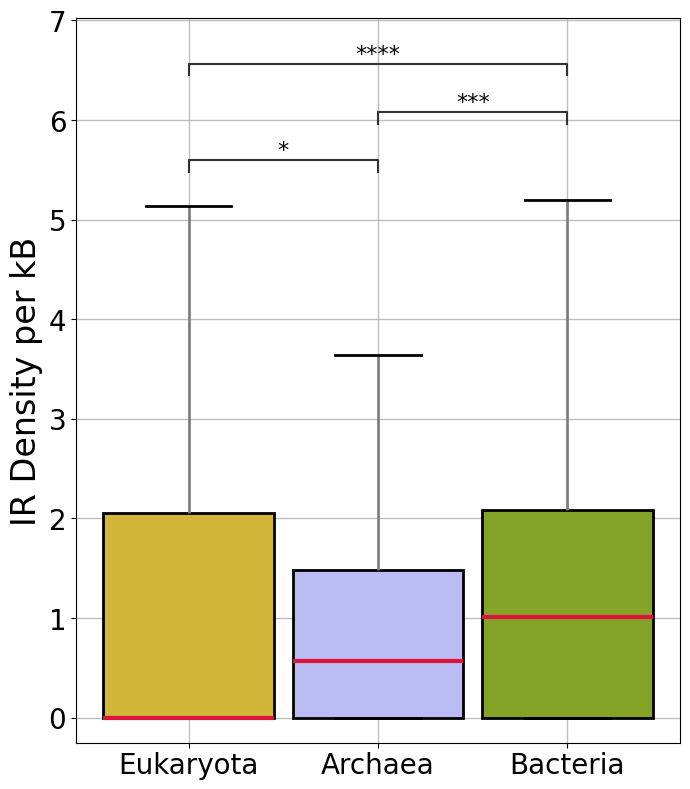

In [125]:

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches as mpatches
from statannotations.Annotator import Annotator

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))

avg_host_density = calculate_average_density(
                                                df_viral_accessions.group_by("species_taxid").agg(
                                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                                    pl.col("genome_size").mean().alias("genome_size"),
                                                    pl.col("domain").first().alias("domain"),
                                                    pl.col("hostRe").first().alias("hostRe")
                                                ).filter(~pl.col("hostRe").is_null()),
                                                on="hostRe",
                                                value=f"density_{pattern}"
                                                )

avg_host_density.loc[:, "domain_color"] = avg_host_density["hostRe"].map(domain_colors)
avg_host_density = avg_host_density.sort_values("mean", ascending=False)

host_STR_density = df_viral_accessions.group_by("species_taxid").agg(
                                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                                pl.col("genome_size").mean().alias("genome_size"),
                                                pl.col("domain").first().alias("domain"),
                                                pl.col("hostRe").first().alias("hostRe")
                                        ).filter(~pl.col("hostRe").is_null())

order = ["Eukaryota", "Archaea", "Bacteria"]

sns.boxplot(data=host_STR_density,
            y=f"density_{pattern}",
            x="hostRe",
            palette=domain_colors,
            width=0.9,
            hue="hostRe",
            linewidth=1.5,
            # edgecolor="black",
            order=order,
            showfliers=False,
            ax=ax,
            # saturation=0.8,
            # capsize=0.4,
            boxprops=dict(linewidth=2, edgecolor='black'),
            medianprops=dict(color='crimson', linewidth=3), 
            whiskerprops=dict(linewidth=2, color='gray'),
            capprops=dict(linewidth=2, color='black'),
            flierprops=dict(marker='o', color='orange', markersize=5)
           )
ax.grid(lw=1.0, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0, pad=2)
ax.set_xlabel('')
ax.set_ylabel(f"{pattern} Density per kB", fontsize=24)
ax.yaxis.label.set_size(24)
ax.tick_params(axis="both", 
               labelsize=20, 
               zorder=0)
ax.legend(handles=[], frameon=False)
pairs=[("Eukaryota", "Archaea"), ("Archaea", "Bacteria"), ("Eukaryota", "Bacteria")]
annotator = Annotator(ax, 
                      pairs, 
                      data=host_STR_density.to_pandas(),
                      x="hostRe",
                      y=f"density_{pattern}",
                      # hue="hostRe",
                      order=order
                     )
annotator.configure(test='Mann-Whitney',  
                    comparisons_correction="fdr_bh",
                    text_format='star',
                    fontsize=16,
                    text_offset=-0.05,
                    loc='inside')
annotator.apply_and_annotate()
target = Path(f"{pattern}_figures/regression").resolve()
plt.tight_layout()
fig.savefig(f"{target}/{pattern}_density_viral_hosts_comparison.pdf", bbox_inches="tight", transparent=True)